In [3]:
# # Double Deep Q-Network (DDQN) for CartPole
# 
# This notebook implements a Double Deep Q-Network to solve the CartPole-v1 environment.
# DDQN improves upon DQN by using two networks to reduce overestimation bias.

# %%
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import gymnasium as gym
from collections import namedtuple, deque
import matplotlib.pyplot as plt
import random
import matplotlib.pyplot as plt
from collections import deque
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

print("Libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")

Libraries imported successfully!
PyTorch version: 1.11.0


In [4]:

# ## Neural Network Architecture
# 
# We'll create a simple feedforward neural network for our Q-function approximation.

# %%
class DQN(nn.Module):
    def __init__(self, input_size=4, hidden_size=128, output_size=2):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Test the network
test_net = DQN()
test_input = torch.randn(1, 4)
test_output = test_net(test_input)
print(f"Network output shape: {test_output.shape}")
print(f"Test output: {test_output}")


Network output shape: torch.Size([1, 2])
Test output: tensor([[-0.1497,  0.0344]], grad_fn=<AddmmBackward0>)


In [5]:
# ## Experience Replay Buffer
# 
# The replay buffer stores experiences and allows us to sample random batches for training.

# %%
class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)
    
    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))
    
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = map(np.stack, zip(*batch))
        return state, action, reward, next_state, done
    
    def __len__(self):
        return len(self.buffer)

# Test the replay buffer
replay_buffer = ReplayBuffer(1000)
print(f"Replay buffer created with capacity: {replay_buffer.buffer.maxlen}")

# %% [markdown]
# ## DDQN Agent
# 
# The DDQN agent uses two networks: one for action selection and one for evaluation.

# %%
class DDQNAgent:
    def __init__(self, state_size=4, action_size=2, lr=0.001):
        self.state_size = state_size
        self.action_size = action_size
        self.lr = lr
        
        # Hyperparameters
        self.gamma = 0.99          # Discount factor
        self.epsilon = 1.0         # Exploration rate
        self.epsilon_decay = 0.995
        self.epsilon_min = 0.01
        self.batch_size = 64
        self.target_update = 100   # Update target network every N steps
        
        # Neural networks
        self.q_network = DQN(state_size, 128, action_size)
        self.target_network = DQN(state_size, 128, action_size)
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=lr)
        
        # Replay buffer
        self.memory = ReplayBuffer(10000)
        self.step_count = 0
        
        # Copy weights to target network
        self.update_target_network()
    
    def update_target_network(self):
        """Copy weights from main network to target network"""
        self.target_network.load_state_dict(self.q_network.state_dict())
    
    def remember(self, state, action, reward, next_state, done):
        """Store experience in replay buffer"""
        self.memory.push(state, action, reward, next_state, done)
    
    def act(self, state):
        """Choose action using epsilon-greedy policy"""
        if np.random.random() <= self.epsilon:
            return random.choice(range(self.action_size))
        
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        q_values = self.q_network(state_tensor)
        return np.argmax(q_values.cpu().data.numpy())
    
    def replay(self):
        """Train the network on a batch of experiences"""
        if len(self.memory) < self.batch_size:
            return
        
        # Sample batch from memory
        states, actions, rewards, next_states, dones = self.memory.sample(self.batch_size)
        
        states = torch.FloatTensor(states)
        actions = torch.LongTensor(actions)
        rewards = torch.FloatTensor(rewards)
        next_states = torch.FloatTensor(next_states)
        dones = torch.BoolTensor(dones)
        
        # Current Q values
        current_q_values = self.q_network(states).gather(1, actions.unsqueeze(1))
        
        # DDQN: Use main network to select actions, target network to evaluate
        next_actions = self.q_network(next_states).max(1)[1].unsqueeze(1)
        next_q_values = self.target_network(next_states).gather(1, next_actions).squeeze(1)
        
        # Calculate target Q values
        target_q_values = rewards + (self.gamma * next_q_values * ~dones)
        
        # Compute loss
        loss = F.mse_loss(current_q_values.squeeze(), target_q_values)
        
        # Optimize
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
        # Update epsilon
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay
        
        # Update target network
        self.step_count += 1
        if self.step_count % self.target_update == 0:
            self.update_target_network()

# Create agent
agent = DDQNAgent()
print("DDQN Agent created successfully!")
print(f"State size: {agent.state_size}")
print(f"Action size: {agent.action_size}")
print(f"Initial epsilon: {agent.epsilon}")

Replay buffer created with capacity: 1000
DDQN Agent created successfully!
State size: 4
Action size: 2
Initial epsilon: 1.0


Starting training...
Episode 0, Average Score: 13.00, Epsilon: 1.000
Episode 50, Average Score: 136.53, Epsilon: 0.010
Environment solved in 99 episodes!
Average Score: 196.15
Training completed!


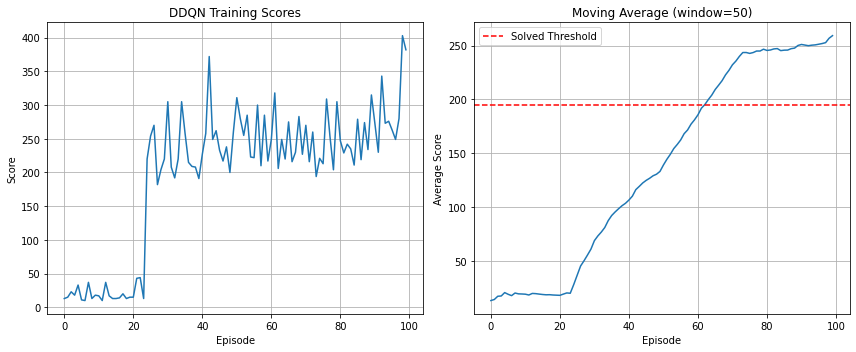


Training Statistics:
Total episodes: 100
Final score: 382.0
Average of last 100 episodes: 196.15
Best score: 403.0


In [6]:
# Now let's train our DDQN agent on the CartPole environment.

# %%
def train_ddqn(episodes=500, max_steps=500):
    env = gym.make('CartPole-v1')
    scores = []
    scores_window = deque(maxlen=100)
    
    for episode in range(episodes):
        state = env.reset()
        if isinstance(state, tuple):  # Handle newer gym versions
            state = state[0]
        
        total_reward = 0
        
        for step in range(max_steps):
            # Choose action
            action = agent.act(state)
            
            # Take action
            next_state, reward, done, _, _ = env.step(action)
            
            # Store experience
            agent.remember(state, action, reward, next_state, done)
            
            # Train agent
            agent.replay()
            
            state = next_state
            total_reward += reward
            
            if done:
                break
        
        scores.append(total_reward)
        scores_window.append(total_reward)
        
        # Print progress
        if episode % 50 == 0:
            avg_score = np.mean(scores_window)
            print(f"Episode {episode}, Average Score: {avg_score:.2f}, Epsilon: {agent.epsilon:.3f}")
        
        # Check if solved
        if len(scores_window) == 100 and np.mean(scores_window) >= 195:
            print(f"Environment solved in {episode} episodes!")
            print(f"Average Score: {np.mean(scores_window):.2f}")
            break
    
    env.close()
    return scores

print("Starting training...")
scores = train_ddqn(episodes=500)
print("Training completed!")

# %% [markdown]
# ## Results Visualization
# 
# Let's plot the training results to see how our agent performed.

# %%
plt.figure(figsize=(12, 5))

# Plot 1: Raw scores
plt.subplot(1, 2, 1)
plt.plot(scores)
plt.title('DDQN Training Scores')
plt.xlabel('Episode')
plt.ylabel('Score')
plt.grid(True)

# Plot 2: Moving average
plt.subplot(1, 2, 2)
moving_avg = []
window = 50
for i in range(len(scores)):
    start_idx = max(0, i - window + 1)
    moving_avg.append(np.mean(scores[start_idx:i+1]))

plt.plot(moving_avg)
plt.title(f'Moving Average (window={window})')
plt.xlabel('Episode')
plt.ylabel('Average Score')
plt.axhline(y=195, color='r', linestyle='--', label='Solved Threshold')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Print final statistics
print(f"\nTraining Statistics:")
print(f"Total episodes: {len(scores)}")
print(f"Final score: {scores[-1]}")
print(f"Average of last 100 episodes: {np.mean(scores[-100:]):.2f}")
print(f"Best score: {max(scores)}")


In [7]:

# ## Testing the Trained Agent
# 
# Let's test our trained agent to see how well it performs.

# %%
def test_agent(episodes=5, render=False):
    env = gym.make('CartPole-v1', render_mode='human' if render else None)
    test_scores = []
    
    # Set epsilon to 0 for testing (no exploration)
    original_epsilon = agent.epsilon
    agent.epsilon = 0
    
    for episode in range(episodes):
        state = env.reset()
        if isinstance(state, tuple):
            state = state[0]
        
        total_reward = 0
        steps = 0
        
        while True:
            action = agent.act(state)
            state, reward, done, _, _ = env.step(action)
            total_reward += reward
            steps += 1
            
            if done:
                break
        
        test_scores.append(total_reward)
        print(f"Test Episode {episode + 1}: Score = {total_reward}, Steps = {steps}")
    
    # Restore original epsilon
    agent.epsilon = original_epsilon
    
    env.close()
    return test_scores

print("Testing trained agent...")
test_scores = test_agent(episodes=5)
print(f"\nTest Results:")
print(f"Average test score: {np.mean(test_scores):.2f}")
print(f"Test scores: {test_scores}")


# ## Key Concepts Explained
# 
# ### Double Deep Q-Network (DDQN)
# 
# DDQN addresses the overestimation problem in DQN by:
# 1. **Action Selection**: Using the main network to select the best action
# 2. **Action Evaluation**: Using the target network to evaluate that action
# 
# This decoupling reduces the overestimation bias that can occur in standard DQN.
# 
# ### Key Components:
# - **Experience Replay**: Stores and samples past experiences for training
# - **Target Network**: Provides stable targets for training
# - **Epsilon-Greedy**: Balances exploration vs exploitation
# - **Double Q-Learning**: Reduces overestimation bias
# 
# ### Hyperparameters:
# - Learning Rate: 0.001
# - Discount Factor (γ): 0.99
# - Batch Size: 64
# - Target Network Update: Every 100 steps
# - Epsilon Decay: 0.995

print("DDQN CartPole example completed successfully!")
print("The agent should be able to solve CartPole (average score ≥ 195) within 500 episodes.")

Testing trained agent...
Test Episode 1: Score = 500.0, Steps = 500
Test Episode 2: Score = 407.0, Steps = 407
Test Episode 3: Score = 474.0, Steps = 474
Test Episode 4: Score = 441.0, Steps = 441
Test Episode 5: Score = 346.0, Steps = 346

Test Results:
Average test score: 433.60
Test scores: [500.0, 407.0, 474.0, 441.0, 346.0]
DDQN CartPole example completed successfully!
The agent should be able to solve CartPole (average score ≥ 195) within 500 episodes.
